In [ ]:
# import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import (
#     BaggingClassifier, RandomForestClassifier,
#     GradientBoostingClassifier, StackingClassifier, VotingClassifier
# )
# from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
# from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
# from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.utils import shuffle as sk_shuffle
from sklearn.metrics import balanced_accuracy_score
import matplotlib.ticker as mticker
import seaborn as sns

## Load Datasets

In [ ]:
df = pd.read_csv('train.csv', na_values=["?"], low_memory=False)
test_df = pd.read_csv('test.csv', na_values=["?"], low_memory=False)
df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307178 entries, 0 to 307177
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDEX_NR              307178 non-null  int64  
 1   INCIDENT_DATE         307178 non-null  object 
 2   INCIDENT_MONTH        307178 non-null  int64  
 3   INCIDENT_YEAR         307178 non-null  int64  
 4   TIME                  197926 non-null  object 
 5   TIME_OF_DAY           173207 non-null  object 
 6   AIRPORT_ID            307178 non-null  object 
 7   AIRPORT               307178 non-null  object 
 8   LATITUDE              266434 non-null  object 
 9   LONGITUDE             266431 non-null  object 
 10  RUNWAY                231593 non-null  object 
 11  STATE                 266434 non-null  object 
 12  FAAREGION             266434 non-null  object 
 13  LOCATION              39218 non-null   object 
 14  OPID                  307178 non-null  object 
 15  

## Data Cleaning

In [ ]:
# [NUM_STRUCK and NUM_SEEN] are numeric features but they have some non-numeric values

df["NUM_STRUCK"] = pd.to_numeric(df["NUM_STRUCK"], errors="coerce")
df["NUM_SEEN"]   = pd.to_numeric(df["NUM_SEEN"],   errors="coerce")

In [ ]:
df.describe()

,INDEX_NR,INCIDENT_MONTH,INCIDENT_YEAR,EMA,EMO,AC_MASS,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,...,HEIGHT,SPEED,DISTANCE,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,NUM_SEEN,NUM_STRUCK,TRANSFER,INDICATED_DAMAGE
count,3.071780e+05,307178.000000,307178.000000,204757.000000,194002.00000,219732.000000,219481.000000,219461.000000,204669.000000,12356.000000,...,152981.000000,95102.000000,203875.000000,307178.000000,307178.000000,307178.000000,60295.0,273277.0,307178.0,307178.000000
mean,1.030746e+06,7.221136,2013.629697,19.308815,8.15889,3.557770,2.004328,2.722128,2.546287,2.909922,...,882.259627,142.973061,0.878159,0.000856,0.538925,0.179821,1.0,1.0,0.0,0.063569
std,3.851711e+05,2.750603,8.991125,10.573812,11.50024,0.865756,0.409663,2.117692,1.958387,1.938278,...,1858.178379,46.550616,3.687059,0.029248,0.498483,0.384039,0.0,0.0,0.0,0.243984
min,6.082420e+05,1.000000,1990.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.0,0.000000
25%,7.054882e+05,5.000000,2008.000000,10.000000,1.00000,3.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.0,0.000000
50%,8.052665e+05,8.000000,2015.000000,22.000000,4.00000,4.000000,2.000000,1.000000,1.000000,1.000000,...,50.000000,140.000000,0.000000,0.000000,1.000000,0.000000,1.0,1.0,0.0,0.000000
75%,1.437907e+06,9.000000,2021.000000,31.000000,10.00000,4.000000,2.000000,5.000000,5.000000,5.000000,...,1000.000000,160.000000,0.000000,0.000000,1.000000,0.000000,1.0,1.0,0.0,0.000000
max,1.825451e+06,12.000000,2026.000000,47.000000,97.00000,5.000000,4.000000,7.000000,7.000000,6.000000,...,32000.000000,541.000000,99.000000,1.000000,1.000000,1.000000,1.0,1.0,0.0,1.000000


In [ ]:
# Figuring out the distribution of NaN values in the dataset
# Total NaN
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

# Amonut of NaN per features
nan_counts = df.isnull().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
nan_df = pd.DataFrame({"NaN Count": nan_counts, "NaN %": nan_pct})
nan_df = nan_df[nan_df["NaN Count"] > 0].sort_values("NaN %", ascending=False)
print(nan_df.to_string())

Total NaN values: 4,719,932
Total cells:      16,894,790
Missing overall:  27.9%

                  NaN Count  NaN %
BIRD_BAND_NUMBER     306465  99.77
ENG_4_POS            303909  98.94
ENROUTE_STATE        301832  98.26
PRECIPITATION        295966  96.35
ENG_3_POS            294822  95.98
LOCATION             267960  87.23
NUM_SEEN             246883  80.37
SPEED                212076  69.04
SKY                  162825  53.01
FLT                  161435  52.55
HEIGHT               154197  50.20
TIME_OF_DAY          133971  43.61
PHASE_OF_FLIGHT      120961  39.38
REG                  118982  38.73
AMO                  116813  38.03
EMO                  113176  36.84
TIME                 109252  35.57
DISTANCE             103303  33.63
COMMENTS             103083  33.56
ENG_2_POS            102509  33.37
EMA                  102421  33.34
AMA                   88896  28.94
TYPE_ENG              87786  28.58
ENG_1_POS             87717  28.56
NUM_ENGS              87697  28.55
AC_MASS 

In [ ]:
# Extract keyword features from REMARKS and COMMENTS before dropping them
# These free text fields contain direct evidence of damage
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold

damage_keywords = [
    # Original keywords
    "engine", "ingested", "windshield", "damaged", "shattered",
    "destroyed", "broken", "cracked", "dented", "punctured",
    "multiple", "fuselage", "prop", "propeller", "landing gear",
    "radome", "nacelle", "wing", "tail",
    # High signal from REMARKS analysis
    "repaired", "replaced", "repair", "repairs", "replacement",
    "penetrated", "deformed", "collapsed", "chipped", "crack",
    "cracks", "dents", "scratch", "scratches", "vibration",
    "vibrations", "failure", "failed", "cancelled", "ferried",
    "ferry", "metal", "hydraulic", "stall", "paint",
    "mechanical", "throttle", "accident", "towed",
    # High signal from COMMENTS analysis
    "emergency", "geese", "goose", "incident", "losses"
]

for keyword in damage_keywords:
    col_name = f"REMARKS_{keyword.replace(' ', '_')}"
    df[col_name]      = df["REMARKS"].str.contains(keyword, case=False, na=False).astype(int)
    test_df[col_name] = test_df["REMARKS"].str.contains(keyword, case=False, na=False).astype(int)

for keyword in damage_keywords:
    col_name = f"COMMENTS_{keyword.replace(' ', '_')}"
    df[col_name]      = df["COMMENTS"].str.contains(keyword, case=False, na=False).astype(int)
    test_df[col_name] = test_df["COMMENTS"].str.contains(keyword, case=False, na=False).astype(int)

# ── TF-IDF on combined REMARKS + COMMENTS ────────────────────────
df["ALL_TEXT"]      = df["REMARKS"].fillna("") + " " + df["COMMENTS"].fillna("")
test_df["ALL_TEXT"] = test_df["REMARKS"].fillna("") + " " + test_df["COMMENTS"].fillna("")

tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 2), min_df=5)
tfidf_train = tfidf.fit_transform(df["ALL_TEXT"])
tfidf_test  = tfidf.transform(test_df["ALL_TEXT"])

tfidf_cols = [f"TFIDF_{c}" for c in tfidf.get_feature_names_out()]
tfidf_train_df = pd.DataFrame(tfidf_train.toarray(), columns=tfidf_cols)
tfidf_test_df  = pd.DataFrame(tfidf_test.toarray(),  columns=tfidf_cols)

df      = pd.concat([df.reset_index(drop=True),      tfidf_train_df], axis=1)
test_df = pd.concat([test_df.reset_index(drop=True), tfidf_test_df],  axis=1)

# Drop ALL_TEXT — no longer needed after TF-IDF
df.drop(columns=["ALL_TEXT"], inplace=True)
test_df.drop(columns=["ALL_TEXT"], inplace=True)

# ── SPECIES count + damage rate encoding ─────────────────────────
df["SPECIES_count"]       = df["SPECIES"].map(df["SPECIES"].value_counts())
df["SPECIES_damage_rate"] = df["SPECIES"].map(df.groupby("SPECIES")["INDICATED_DAMAGE"].mean())

test_df["SPECIES_count"]       = test_df["SPECIES"].map(df["SPECIES"].value_counts()).fillna(0)
test_df["SPECIES_damage_rate"] = test_df["SPECIES"].map(
    df.groupby("SPECIES")["INDICATED_DAMAGE"].mean()
).fillna(df["INDICATED_DAMAGE"].mean())

# ── Target encoding with CV to avoid leakage ─────────────────────
def target_encode_cv(train_df, col, target, n_splits=5):
    encoded = pd.Series(index=train_df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    global_mean = train_df[target].mean()
    for train_idx, val_idx in kf.split(train_df):
        mean_map = train_df.iloc[train_idx].groupby(col)[target].mean()
        encoded.iloc[val_idx] = train_df.iloc[val_idx][col].map(mean_map).fillna(global_mean)
    return encoded

target_enc_cols = ["SPECIES", "AIRPORT", "OPERATOR", "STATE", "PHASE_OF_FLIGHT", "SPECIES_ID"]
target_encoders_map = {}

for col in target_enc_cols:
    if col in df.columns:
        df[col + "_TE"] = target_encode_cv(df, col, "INDICATED_DAMAGE")
        target_encoders_map[col] = df.groupby(col)["INDICATED_DAMAGE"].mean()

# Apply target encoding to test set using full training mean
for col in target_enc_cols:
    if col in test_df.columns:
        test_df[col + "_TE"] = test_df[col].map(
            target_encoders_map[col]
        ).fillna(df["INDICATED_DAMAGE"].mean())

text_features = [c for c in df.columns if c.startswith("REMARKS_") or c.startswith("COMMENTS_")]
print(f"Keyword features: {len(text_features)}")
print(f"TF-IDF features:  {len(tfidf_cols)}")
print(f"Target enc feats: {len(target_enc_cols)}")
print(f"Total df shape:   {df.shape}")

Text features added: 38
['REMARKS_engine', 'REMARKS_ingested', 'REMARKS_windshield', 'REMARKS_damaged', 'REMARKS_shattered', 'REMARKS_destroyed', 'REMARKS_broken', 'REMARKS_cracked', 'REMARKS_dented', 'REMARKS_punctured', 'REMARKS_multiple', 'REMARKS_fuselage', 'REMARKS_prop', 'REMARKS_propeller', 'REMARKS_landing_gear', 'REMARKS_radome', 'REMARKS_nacelle', 'REMARKS_wing', 'REMARKS_tail', 'COMMENTS_engine', 'COMMENTS_ingested', 'COMMENTS_windshield', 'COMMENTS_damaged', 'COMMENTS_shattered', 'COMMENTS_destroyed', 'COMMENTS_broken', 'COMMENTS_cracked', 'COMMENTS_dented', 'COMMENTS_punctured', 'COMMENTS_multiple', 'COMMENTS_fuselage', 'COMMENTS_prop', 'COMMENTS_propeller', 'COMMENTS_landing_gear', 'COMMENTS_radome', 'COMMENTS_nacelle', 'COMMENTS_wing', 'COMMENTS_tail']

Damage rate by keyword presence (training set):
  REMARKS_engine                      count= 27173 | damage_rate=0.077
  REMARKS_ingested                    count=  3429 | damage_rate=0.315
  REMARKS_windshield           

In [ ]:
# Dropping features due to high precentage of NaN
# Additionally dropping random features that act as Identifiers (i.e. INCIDENT_DATE, FLT, REG, LUPDATE, TRANSFER)
# [LOCATION, COMMENTS, REMARKS] since they are free text
# [LATITUDE and LONGTITUDE] are redudant
# [NUM_SEEN, NUM_STRUCK, TRANSFER, and OUT_OF_RANGE_SPECIES] contain no varianece
# [RUNWAY] high cardinality
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "LATITUDE", "LONGITUDE",
    "NUM_SEEN", "NUM_STRUCK", "TRANSFER", "OUT_OF_RANGE_SPECIES", "RUNWAY"
]
df = df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

In [ ]:
# Fill the numeric features's NaN value with there respective median
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]

train_medians = {}
for col in num_cols:
    if col in df.columns:
        train_medians[col] = df[col].median()
        df[col] = df[col].fillna(train_medians[col])
        test_df[col] = test_df[col].fillna(train_medians[col])

In [ ]:
# Fill the categorical features's NaN with "Unknown"
cat_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
            "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
            "FAAREGION", "PERSON", "SOURCE", "AMO", "AMA",
            "SPECIES_ID"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")
        test_df[col] = test_df[col].fillna("Unknown")

In [ ]:
# Checking NaN percentage
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

Total NaN values: 109,252
Total cells:      22,731,172
Missing overall:  0.5%



In [ ]:
# Convert TIME (HH:MM string) to numeric HOUR, then drop original
# Missing TIME values are imputed with the median hour
df["HOUR"] = pd.to_numeric(
    df["TIME"].str.split(":").str[0], errors="coerce"
)
test_df["HOUR"] = pd.to_numeric(
    test_df["TIME"].str.split(":").str[0], errors="coerce"
)
train_medians["HOUR"] = df["HOUR"].median()
df["HOUR"] = df["HOUR"].fillna(train_medians["HOUR"])
test_df["HOUR"] = test_df["HOUR"].fillna(train_medians["HOUR"])
df = df.drop(columns=["TIME"])
test_df = test_df.drop(columns=["TIME"])

print("HOUR sample:", df["HOUR"].describe())
print("\nRemaining NaNs:", df.isnull().sum().sum())

HOUR sample: count    307178.000000
mean         12.588639
std           4.616758
min           0.000000
25%          11.000000
50%          12.000000
75%          14.000000
max          23.000000
Name: HOUR, dtype: float64

Remaining NaNs: 0


In [ ]:
df.shape

(307178, 74)

## Data Exploration

In [ ]:
# Class balance check
print("Class counts:")
print(df["INDICATED_DAMAGE"].value_counts())

print("\nClass percentages:")
print(df["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))


Class counts:
INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64

Class percentages:
INDICATED_DAMAGE
0    93.64
1     6.36
Name: proportion, dtype: float64


In [ ]:
TARGET = "INDICATED_DAMAGE"

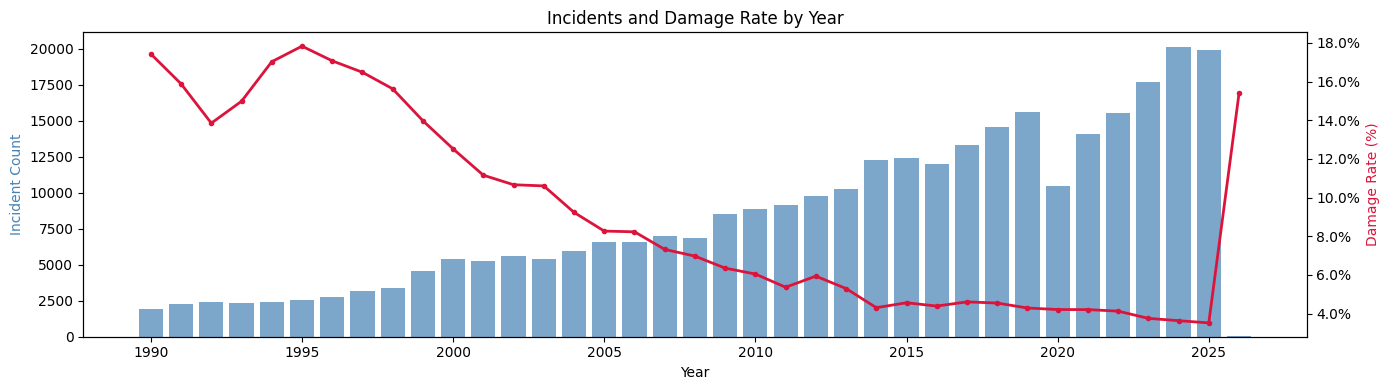

   INCIDENT_YEAR  count  damage_rate
5           1995   2541     0.178276
0           1990   1911     0.174254
6           1996   2730     0.170696
4           1994   2426     0.170239
7           1997   3174     0.164776


In [ ]:
# Incident count and damage rate by year
yearly = df.groupby("INCIDENT_YEAR").agg(
    count=(TARGET, "count"),
    damage_rate=(TARGET, "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(yearly["INCIDENT_YEAR"], yearly["count"], color="steelblue", alpha=0.7, label="Incident count")
ax2.plot(yearly["INCIDENT_YEAR"], yearly["damage_rate"] * 100, color="crimson", linewidth=2, marker="o", markersize=3, label="Damage rate %")

ax1.set_xlabel("Year")
ax1.set_ylabel("Incident Count", color="steelblue")
ax2.set_ylabel("Damage Rate (%)", color="crimson")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.title("Incidents and Damage Rate by Year")
fig.tight_layout()
plt.show()

print(yearly.sort_values("damage_rate", ascending=False).head(5))

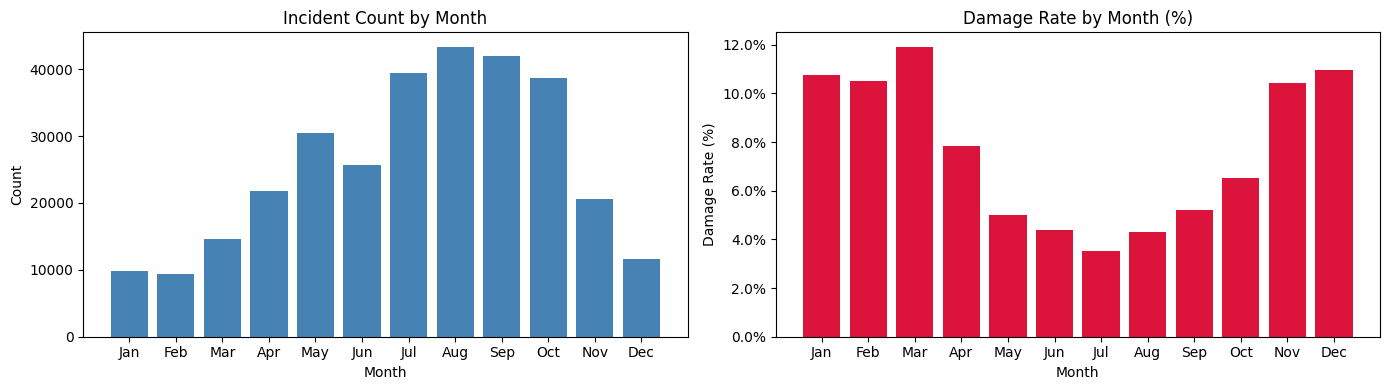

In [ ]:
# Incident count and damage rate by month
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("INCIDENT_MONTH").agg(
    count=(TARGET, "count"),
    damage_rate=(TARGET, "mean")
).reset_index()
monthly["month_name"] = monthly["INCIDENT_MONTH"].apply(lambda x: month_names[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly["month_name"], monthly["count"], color="steelblue")
axes[0].set_title("Incident Count by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Count")

axes[1].bar(monthly["month_name"], monthly["damage_rate"] * 100, color="crimson")
axes[1].set_title("Damage Rate by Month (%)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Damage Rate (%)")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()

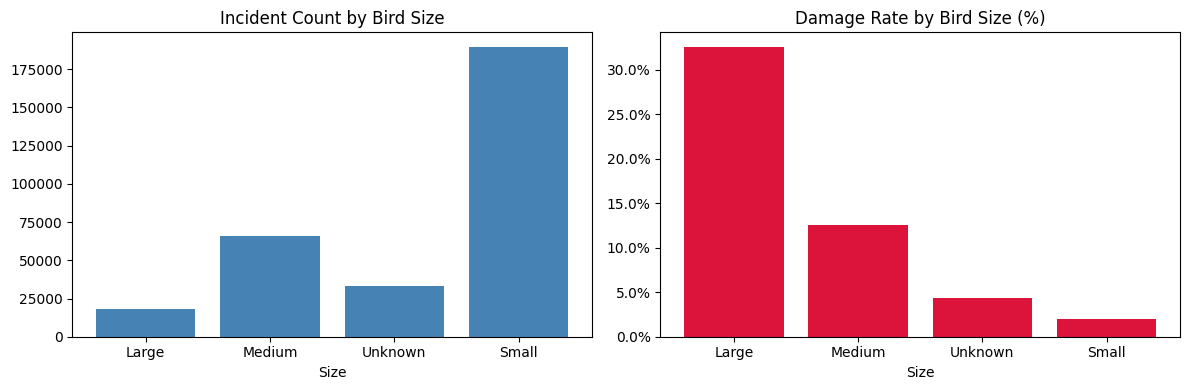

   SIZE  count  damage_rate
  Large  18378     0.325879
 Medium  65601     0.126019
Unknown  33507     0.044080
  Small 189692     0.020001


In [ ]:
# Bird size distribution and damage rate
size_stats = df.groupby("SIZE").agg(
    count=(TARGET, "count"),
    damage_rate=(TARGET, "mean")
).reset_index().dropna(subset=["SIZE"]).sort_values("damage_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(size_stats["SIZE"], size_stats["count"], color="steelblue")
axes[0].set_title("Incident Count by Bird Size")
axes[0].set_xlabel("Size")

axes[1].bar(size_stats["SIZE"], size_stats["damage_rate"] * 100, color="crimson")
axes[1].set_title("Damage Rate by Bird Size (%)")
axes[1].set_xlabel("Size")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()
print(size_stats.to_string(index=False))

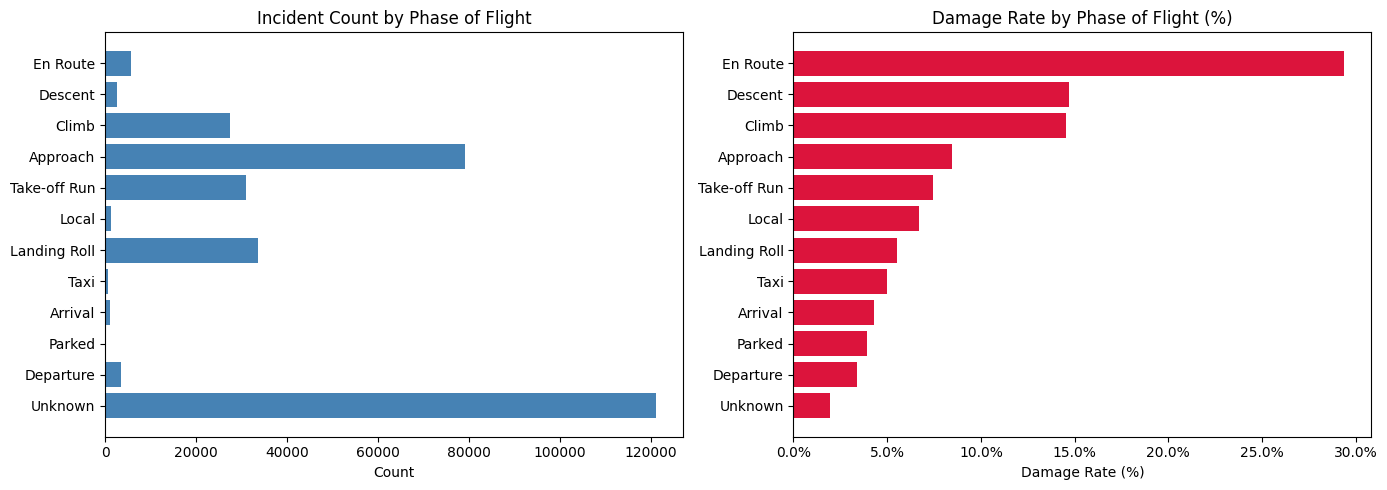

PHASE_OF_FLIGHT  count  damage_rate
       En Route   5600     0.293571
        Descent   2630     0.146768
          Climb  27446     0.145449
       Approach  79162     0.084472
   Take-off Run  31013     0.074259
          Local   1368     0.067251
   Landing Roll  33642     0.055169
           Taxi    718     0.050139
        Arrival    958     0.042797
         Parked    102     0.039216
      Departure   3569     0.034183
        Unknown 120970     0.019542


In [ ]:
# Phase of flight distribution and damage rate
phase_stats = df.groupby("PHASE_OF_FLIGHT").agg(
    count=(TARGET, "count"),
    damage_rate=(TARGET, "mean")
).reset_index().dropna(subset=["PHASE_OF_FLIGHT"]).sort_values("damage_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(phase_stats["PHASE_OF_FLIGHT"][::-1], phase_stats["count"][::-1], color="steelblue")
axes[0].set_title("Incident Count by Phase of Flight")
axes[0].set_xlabel("Count")

axes[1].barh(phase_stats["PHASE_OF_FLIGHT"][::-1], phase_stats["damage_rate"][::-1] * 100, color="crimson")
axes[1].set_title("Damage Rate by Phase of Flight (%)")
axes[1].set_xlabel("Damage Rate (%)")
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()
print(phase_stats.to_string(index=False))

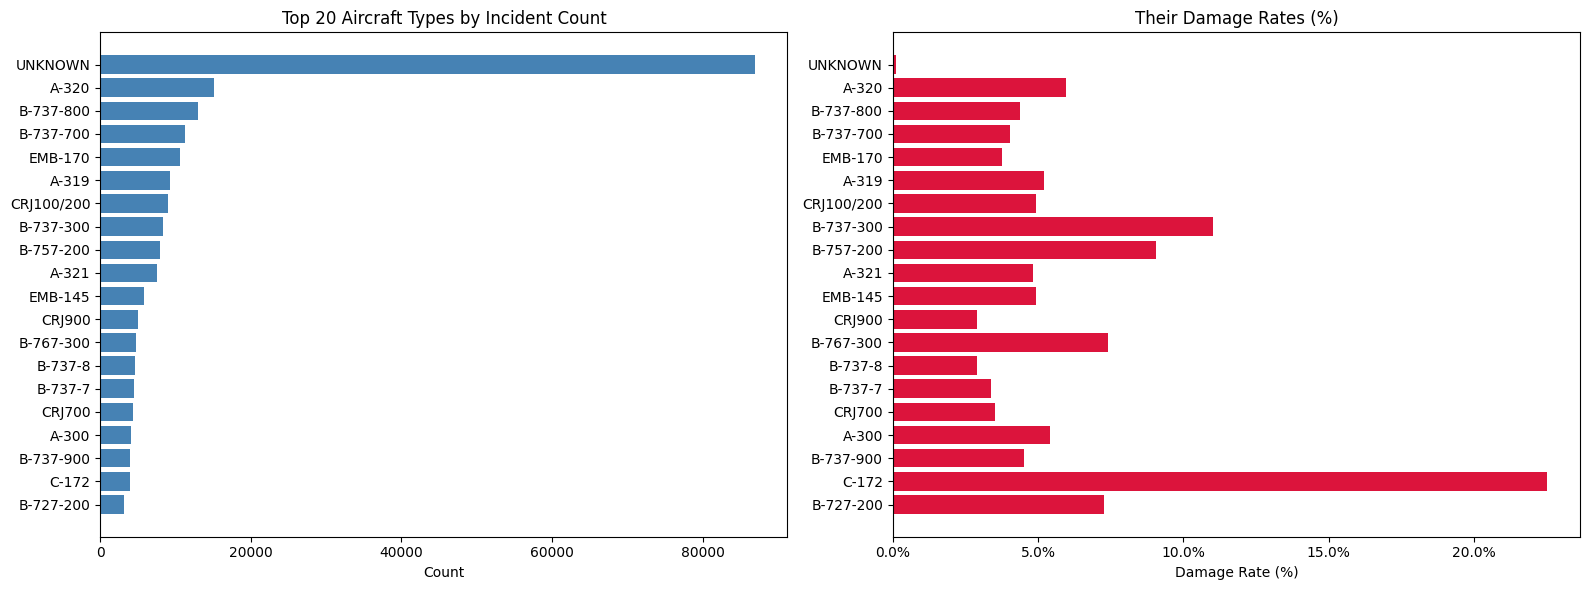

In [ ]:
aircraft_stats = df.groupby("AIRCRAFT").agg(
    count=(TARGET, "count"),
    damage_rate=(TARGET, "mean")
).reset_index()

top_aircraft = aircraft_stats[aircraft_stats["count"] >= 100].sort_values("count", ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_aircraft["AIRCRAFT"][::-1], top_aircraft["count"][::-1], color="steelblue")
axes[0].set_title("Top 20 Aircraft Types by Incident Count")
axes[0].set_xlabel("Count")

axes[1].barh(top_aircraft["AIRCRAFT"][::-1], top_aircraft["damage_rate"][::-1] * 100, color="crimson")
axes[1].set_title("Their Damage Rates (%)")
axes[1].set_xlabel("Damage Rate (%)")
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.show()

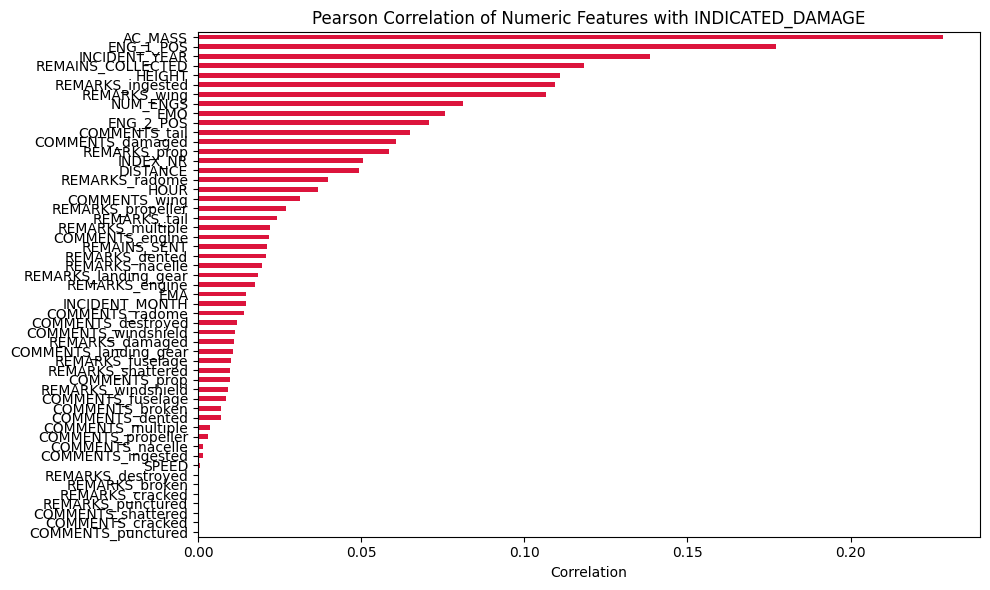

AC_MASS                  0.228270
ENG_1_POS                0.177108
INCIDENT_YEAR            0.138649
REMAINS_COLLECTED        0.118433
HEIGHT                   0.110989
REMARKS_ingested         0.109348
REMARKS_wing             0.106562
NUM_ENGS                 0.081316
EMO                      0.075835
ENG_2_POS                0.070716
COMMENTS_tail            0.064952
COMMENTS_damaged         0.060675
REMARKS_prop             0.058467
INDEX_NR                 0.050603
DISTANCE                 0.049375
REMARKS_radome           0.039888
HOUR                     0.036735
COMMENTS_wing            0.031214
REMARKS_propeller        0.027065
REMARKS_tail             0.024076
REMARKS_multiple         0.021969
COMMENTS_engine          0.021781
REMAINS_SENT             0.021216
REMARKS_dented           0.020738
REMARKS_nacelle          0.019663
REMARKS_landing_gear     0.018457
REMARKS_engine           0.017369
EMA                      0.014691
INCIDENT_MONTH           0.014655
COMMENTS_radom

In [ ]:
# Point-biserial correlation of numeric features with INDICATED_DAMAGE
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]

corr_with_target = (
    df[numeric_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
corr_with_target.plot(kind="barh", color="crimson")
plt.title("Pearson Correlation of Numeric Features with INDICATED_DAMAGE")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(corr_with_target)

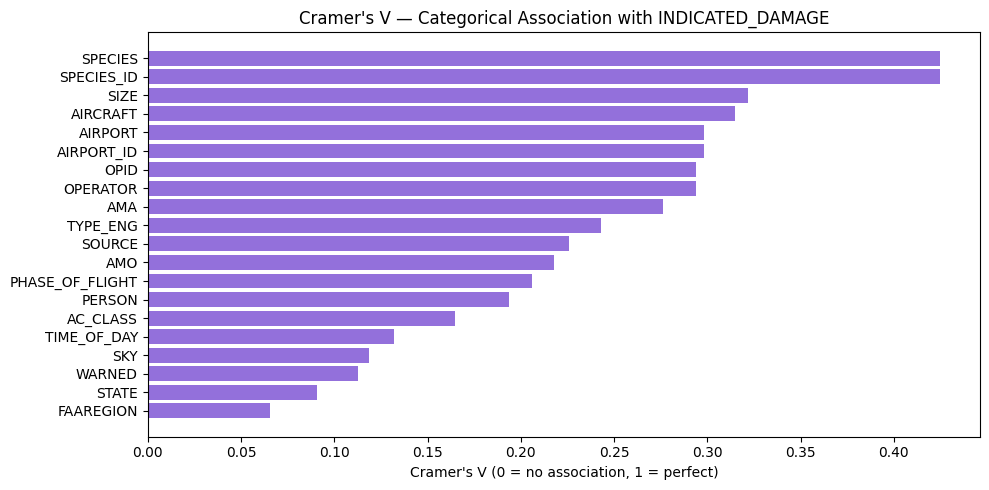

        feature         chi2       p_value  cramers_v
        SPECIES 55454.900623  0.000000e+00   0.424888
     SPECIES_ID 55454.900623  0.000000e+00   0.424888
           SIZE 31802.996785  0.000000e+00   0.321765
       AIRCRAFT 30424.598023  0.000000e+00   0.314715
        AIRPORT 27330.444352  0.000000e+00   0.298283
     AIRPORT_ID 27324.374422  0.000000e+00   0.298250
           OPID 26556.698308  0.000000e+00   0.294030
       OPERATOR 26524.753734  0.000000e+00   0.293853
            AMA 23391.166793  0.000000e+00   0.275950
       TYPE_ENG 18153.018416  0.000000e+00   0.243097
         SOURCE 15698.006366  0.000000e+00   0.226062
            AMO 14553.721026  0.000000e+00   0.217667
PHASE_OF_FLIGHT 13055.307056  0.000000e+00   0.206157
         PERSON 11533.602218  0.000000e+00   0.193770
       AC_CLASS  8348.032364  0.000000e+00   0.164853
    TIME_OF_DAY  5351.981280  0.000000e+00   0.131996
            SKY  4335.207035  0.000000e+00   0.118798
         WARNED  3891.104079

In [ ]:
from scipy.stats import chi2_contingency

cat_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
            "AC_CLASS", "TYPE_ENG", "WARNED", "STATE", "FAAREGION"]

chi2_results = []
for col in df.select_dtypes(include=["object"]).columns:
    sub = df[[col, TARGET]].dropna()
    ct = pd.crosstab(sub[col], sub[TARGET])
    chi2, p, dof, _ = chi2_contingency(ct)
    # Cramer's V as effect size
    n = sub.shape[0]
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({"feature": col, "chi2": chi2, "p_value": p, "cramers_v": cramers_v})

chi2_df = pd.DataFrame(chi2_results).sort_values("cramers_v", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(chi2_df["feature"][::-1], chi2_df["cramers_v"][::-1], color="mediumpurple")
plt.title("Cramer's V — Categorical Association with INDICATED_DAMAGE")
plt.xlabel("Cramer's V (0 = no association, 1 = perfect)")
plt.tight_layout()
plt.show()
print(chi2_df.to_string(index=False))

## Feature Engineering

In [ ]:
# Scaling the data set
# Frequency encoding for high cardinality columns
# Replaces each category with how often it appears in training
high_card_cols = ["SPECIES", "AIRPORT", "AIRPORT_ID", "OPERATOR", "OPID", "AIRCRAFT"]
freq_encoders = {}
for col in high_card_cols:
    if col in df.columns:
        freq = df[col].value_counts() / len(df)
        freq_encoders[col] = freq
        df[col] = df[col].map(freq).fillna(0)

# Label encode remaining categorical columns
label_encoders = {}
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Separate features and target
X = df.drop(columns=["INDICATED_DAMAGE", "INDEX_NR"])
y = df["INDICATED_DAMAGE"]

# Scale
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling complete. Shape:", X_scaled.shape)
print(X_scaled.describe().round(2))

Scaling complete. Shape: (307178, 72)
       INCIDENT_MONTH  INCIDENT_YEAR  TIME_OF_DAY  AIRPORT_ID    AIRPORT  \
count       307178.00      307178.00    307178.00   307178.00  307178.00   
mean            -0.19          -0.11        -0.11        1.60       1.60   
std              0.69           0.69         0.46        3.98       3.98   
min             -1.75          -1.92        -1.00       -0.65      -0.65   
25%             -0.75          -0.54        -0.67       -0.47      -0.47   
50%              0.00           0.00         0.00        0.00       0.00   
75%              0.25           0.46         0.33        0.53       0.53   
max              1.00           0.85         0.33       11.62      11.62   

           STATE  FAAREGION       OPID   OPERATOR   AIRCRAFT  ...  \
count  307178.00  307178.00  307178.00  307178.00  307178.00  ...   
mean       -0.01      -0.08       0.14       0.14       0.24  ...   
std         0.47       0.54       0.41       0.41       0.44  ...   
m

In [ ]:
# Apply frequency encoding using training frequencies
for col in high_card_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].map(freq_encoders[col]).fillna(0)

# Label encode remaining categorical columns using saved encoders
for col in cat_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str).map(
            lambda x, le=label_encoders[col]: le.transform([x])[0]
            if x in le.classes_ else -1
        )

In [ ]:
# Save INDEX_NR before dropping
index_nr = test_df["INDEX_NR"]
X_test = test_df.drop(columns=["INDEX_NR"])

# Force convert every column, catches mixed type columns the dtype check misses
# THIS SECTION IS CLAUDE
for col in X_test.columns:
    try:
        X_test[col] = X_test[col].astype(float)
    except (ValueError, TypeError):
        print(f"Encoding: {col} | sample values: {X_test[col].unique()[:5]}")
        if col in label_encoders:
            X_test[col] = X_test[col].astype(str).map(
                lambda x, le=label_encoders[col]: le.transform([x])[0]
                if x in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X_test[col] = le.fit_transform(X_test[col].astype(str))
            print(f"  Warning: {col} was not in label_encoders, fit new encoder")

# Scale
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Test set ready. Shape:", X_test_scaled.shape)
print("Remaining NaNs:", X_test_scaled.isnull().sum().sum())

Test set ready. Shape: (34131, 72)
Remaining NaNs: 0


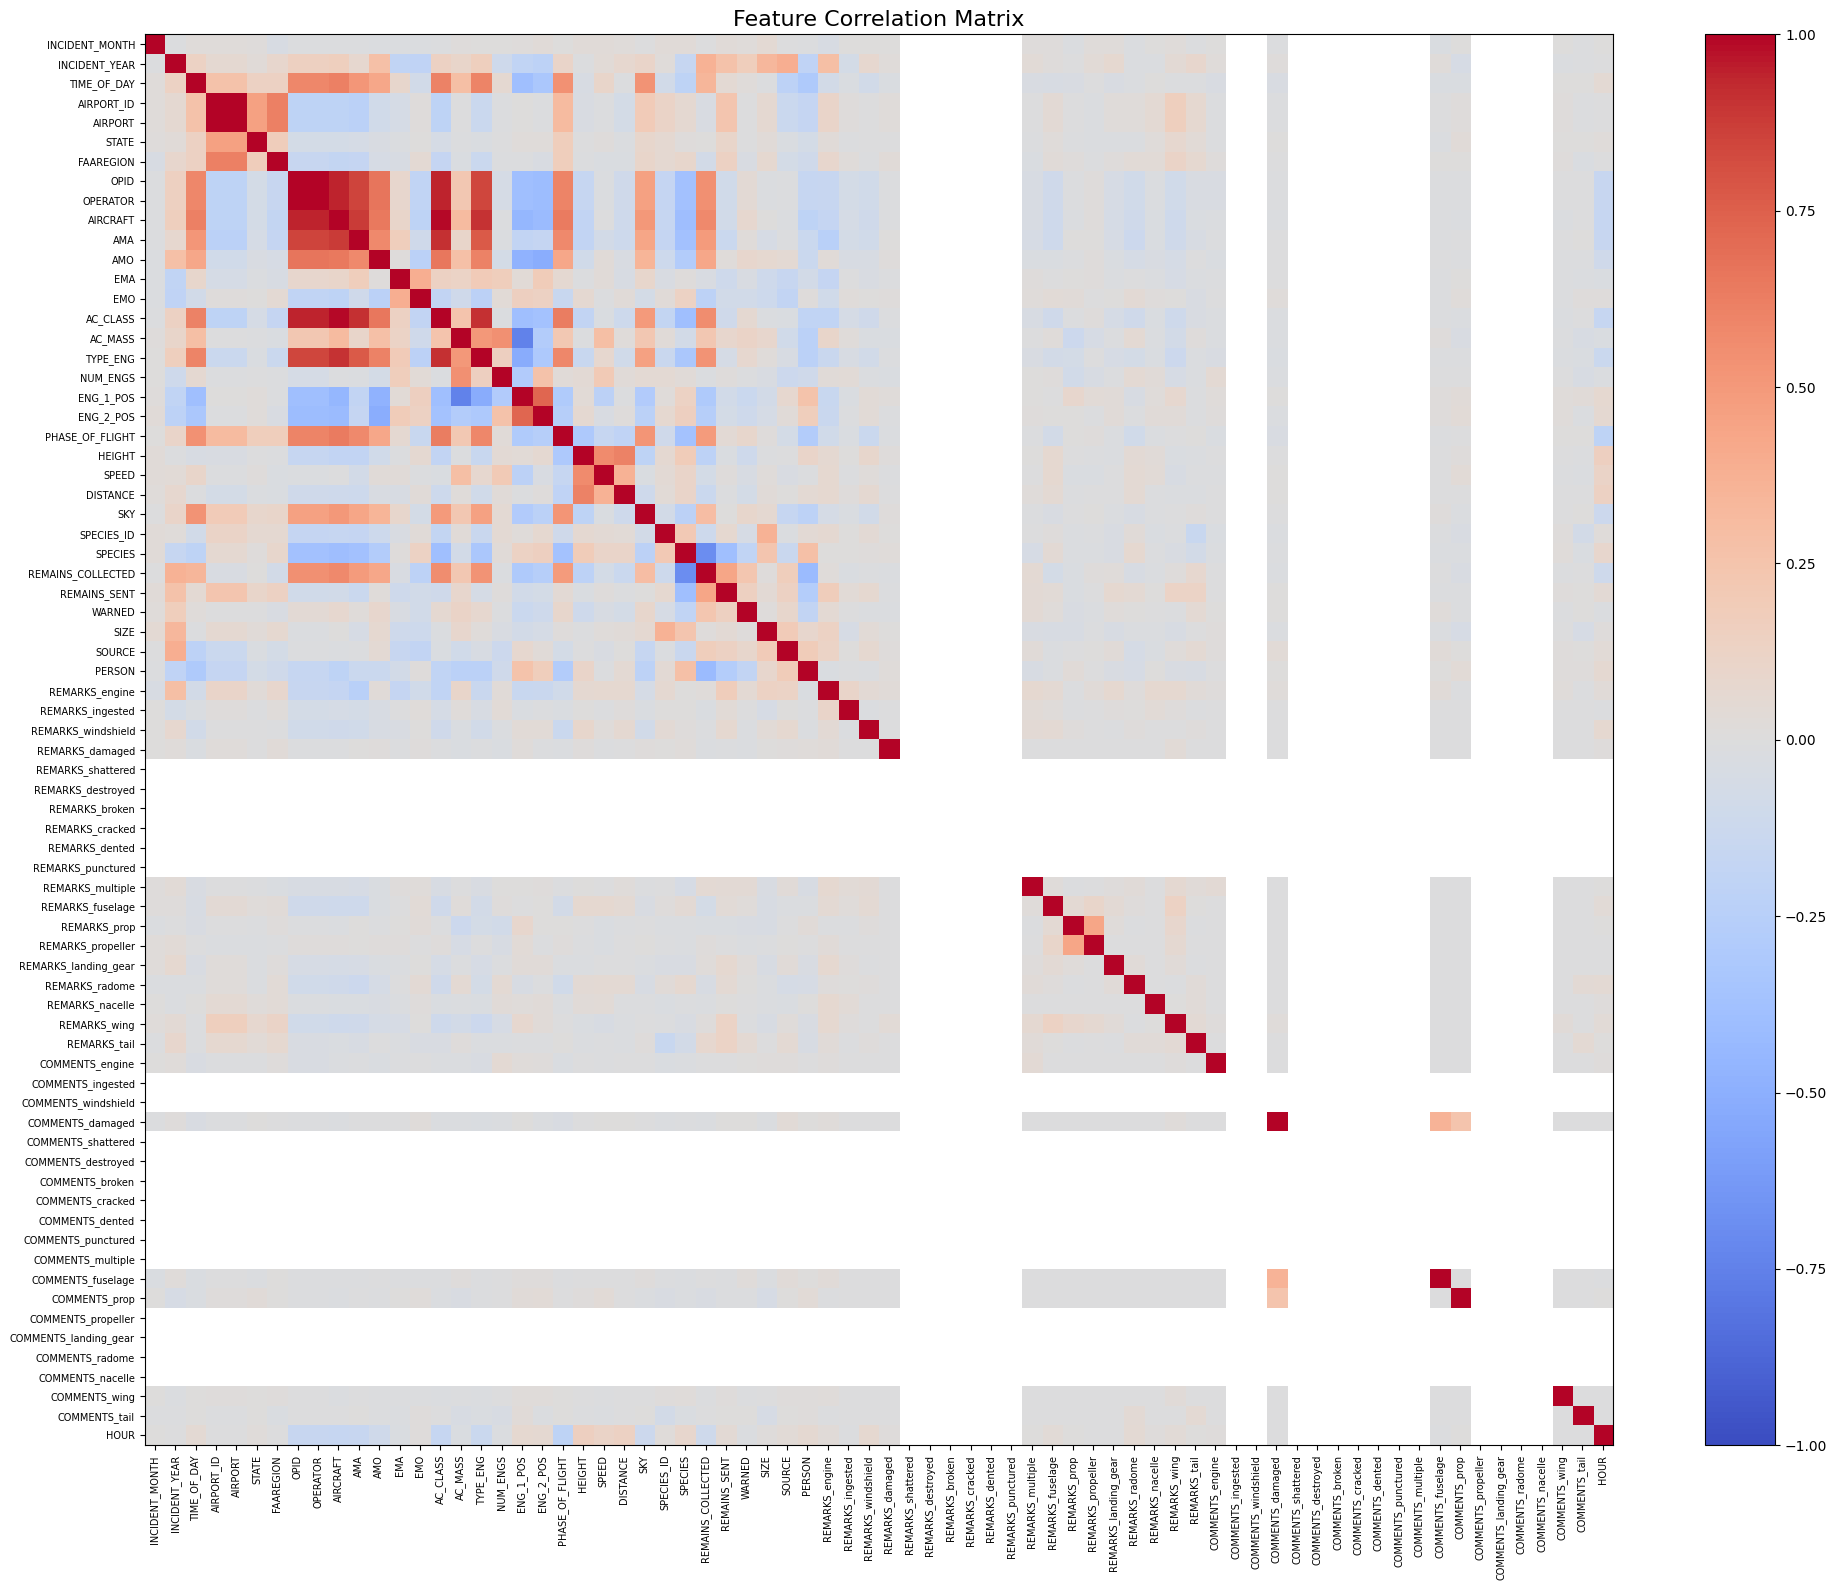

Top 15 features most correlated with INDICATED_DAMAGE:
SIZE                 0.268432
AC_MASS              0.228270
TYPE_ENG             0.205368
ENG_1_POS            0.177108
AIRCRAFT             0.173626
AC_CLASS             0.153370
OPID                 0.147284
OPERATOR             0.147279
SPECIES_ID           0.139793
INCIDENT_YEAR        0.138649
PHASE_OF_FLIGHT      0.131628
AMO                  0.130590
REMAINS_COLLECTED    0.118433
AMA                  0.112025
HEIGHT               0.110989
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# Making similarity matrix to see if data is clusterable (We aren't clustering)
# Sample 5000 rows — computing on 307k rows is too slow
X_sample = X_scaled.sample(n=5000, random_state=42)

corr_matrix = X_sample.corr()

fig, ax = plt.subplots(figsize=(20, 16))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

# Add colorbar
plt.colorbar(im, ax=ax)

# Add feature labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.columns, fontsize=7)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# Top features correlated with target
target_corr = X_scaled.corrwith(y.reset_index(drop=True)).abs().sort_values(ascending=False)
print("Top 15 features most correlated with INDICATED_DAMAGE:")
print(target_corr.head(15))


In [ ]:
# Dropping featues that have near-zero variance
zero_var_cols = ["NUM_SEEN", "NUM_STRUCK", "OUT_OF_RANGE_SPECIES"]
for col in zero_var_cols:
    if col in X_scaled.columns:
        X_scaled = X_scaled.drop(columns=[col])

# Drop zero-variance columns from test set
for col in zero_var_cols:
    if col in X_test_scaled.columns:
        X_test_scaled = X_test_scaled.drop(columns=[col])

print("Remaining training features:", X_scaled.shape[1])
print("Remaining test features:", X_test_scaled.shape[1])

Remaining training features: 72
Remaining test features: 72


In [ ]:
# Check feature importance and drop zero importance features
from xgboost import XGBClassifier

neg   = (y == 0).sum()
pos   = (y == 1).sum()
scale = neg / pos

quick_model = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
quick_model.fit(X_scaled, y)

feat_importance = pd.Series(
    quick_model.feature_importances_,
    index=X_scaled.columns
).sort_values(ascending=False)

print("Top 20 most important features:")
print(feat_importance.head(20))

print("\nBottom 20 least important features:")
print(feat_importance.tail(20))

# Drop features with zero importance
zero_imp = feat_importance[feat_importance == 0].index.tolist()
print(f"\nFeatures with zero importance: {len(zero_imp)}")
print(zero_imp)

if len(zero_imp) > 0:
    X_scaled      = X_scaled.drop(columns=zero_imp)
    X_test_scaled = X_test_scaled.drop(columns=zero_imp)
    print(f"Shape after dropping: {X_scaled.shape}")

In [ ]:
# Fill any remaining NaNs with 0 (= median after RobustScaler)
X_scaled = X_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

print("NaNs remaining in X_scaled:", X_scaled.isnull().sum().sum())
print("NaNs remaining in X_test_scaled:", X_test_scaled.isnull().sum().sum())

# Reset and clean y before model training
y = df["INDICATED_DAMAGE"].reset_index(drop=True)

# Drop any rows where target is NaN
mask = y.notna()
y = y[mask].reset_index(drop=True)
X_scaled = X_scaled[mask].reset_index(drop=True)

print("NaNs in y:", y.isnull().sum())
print("X_scaled shape:", X_scaled.shape)
print("Class counts:\n", y.value_counts())

NaNs remaining in X_scaled: 0
NaNs remaining in X_test_scaled: 0
NaNs in y: 0
X_scaled shape: (307178, 72)
Class counts:
 INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64


In [ ]:
# # Keep all damage records, undersample no-damage to get 60/40 split
# damage_idx    = y[y == 1].index
# no_damage_idx = y[y == 0].index

# n_damage    = len(damage_idx)
# n_no_damage = int(n_damage * 1.5)  # 60% no-damage, 40% damage

# no_damage_sampled_idx = no_damage_idx.to_series().sample(
#     n=n_no_damage, random_state=42
# ).index

# keep_idx = damage_idx.tolist() + no_damage_sampled_idx.tolist()
# X_scaled = X_scaled.loc[keep_idx].reset_index(drop=True)
# y        = y.loc[keep_idx].reset_index(drop=True)

# X_scaled, y = sk_shuffle(X_scaled, y, random_state=42)
# X_scaled = X_scaled.reset_index(drop=True)
# y        = y.reset_index(drop=True)

# print("After undersampling:")
# print("  Total rows:    ", len(y))
# print("  Damage (1):    ", (y == 1).sum(), f"({(y==1).mean()*100:.1f}%)")
# print("  No damage (0): ", (y == 0).sum(), f"({(y==0).mean()*100:.1f}%)")

## Modeling Approach

In [ ]:
n_bags = 20
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

bag_probas_test  = []
bag_probas_train = []

# Recalculate scale_pos_weight on full dataset
neg   = (y == 0).sum()
pos   = (y == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

xgb_params = {
    "n_estimators":      [500, 700, 1000, 1500],   # added 1500
    "learning_rate":     [0.01, 0.03, 0.05, 0.1],  # added 0.03
    "max_depth":         [3, 5, 7, 9],              # added 9
    "subsample":         [0.7, 0.8, 0.9, 1.0],     # added 0.9
    "colsample_bytree":  [0.6, 0.7, 0.8, 1.0],     # added 0.6
    "min_child_weight":  [1, 5, 10, 20],            # added 20
    "gamma":             [0, 0.1, 0.3, 0.5],        # added 0.3
    "reg_alpha":         [0, 0.1, 0.5, 1.0],        # added 0.5
    "reg_lambda":        [1, 2, 5, 10]              # added 10
}

for bag in range(n_bags):
    print(f"\nTraining bag {bag+1}/{n_bags}...")

    # Bootstrap sample 80% of full dataset — different sample each bag
    sampled_idx = y.sample(frac=0.9, random_state=bag).index
    X_bag = X_scaled.loc[sampled_idx].reset_index(drop=True)
    y_bag = y.loc[sampled_idx].reset_index(drop=True)

    print(f"  Bag size: {X_bag.shape[0]} | Damage: {(y_bag==1).sum()} | No damage: {(y_bag==0).sum()}")

    search = RandomizedSearchCV(
        XGBClassifier(
            scale_pos_weight=scale,
            random_state=bag,
            eval_metric="logloss",
            n_jobs=-1
        ),
        xgb_params, n_iter=20  ,
        scoring="balanced_accuracy",
        cv=inner_cv, n_jobs=-1, random_state=bag
    )
    search.fit(X_bag, y_bag)
    best_model = search.best_estimator_

    print(f"  Best params: {search.best_params_}")
    print(f"  CV score: {search.best_score_:.4f}")

    bag_probas_test.append(best_model.predict_proba(X_test_scaled)[:, 1])
    bag_probas_train.append(best_model.predict_proba(X_scaled)[:, 1])
    print(f"  Bag {bag+1} done")

# Average probabilities across all bags
y_proba_test_bagged  = np.mean(bag_probas_test,  axis=0)
y_proba_train_bagged = np.mean(bag_probas_train, axis=0)

# Tune threshold
best_thresh, best_score = 0.5, 0
for thresh in [i/1000 for i in range(100, 600)]:
    preds = (y_proba_train_bagged >= thresh).astype(int)
    score = balanced_accuracy_score(y, preds)
    if score > best_score:
        best_score = score
        best_thresh = thresh

print(f"  Bagged XGBoost ({n_bags} bags, tuned)    ")
print(f"  Train Balanced Accuracy: {best_score:.4f} ")
print(f"  Best threshold:          {best_thresh:.3f}")

scale_pos_weight: 14.73

Training bag 1/10...
  Bag size: 245742 | Damage: 15646 | No damage: 230096
  Best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
  CV score: 0.8347
  Bag 1 done

Training bag 2/10...
  Bag size: 245742 | Damage: 15673 | No damage: 230069
  Best params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}
  CV score: 0.8355
  Bag 2 done

Training bag 3/10...
  Bag size: 245742 | Damage: 15583 | No damage: 230159
  Best params: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
  CV score: 0.8344
  Bag 3 done

Training bag 4/10...
  Bag size: 245742 | Damage: 15632 | No damage: 230110
 

In [ ]:
# Generate submission
y_pred_bagged = (y_proba_test_bagged >= best_thresh).astype(int)

submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred_bagged
})
submission.to_csv("submission_bagged_tuned.csv", index=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# DECISION STUMP (Decision Tree with max_depth=1)
stump_params = {
    "class_weight": ["balanced"],
    "criterion":    ["gini", "entropy"],
    "splitter":     ["best", "random"]
}
stump_search = RandomizedSearchCV(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    stump_params, n_iter=6, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
stump_search.fit(X_scaled, y)
best_stump = stump_search.best_estimator_

stump_scores = cross_val_score(best_stump, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Decision Stump ──")
print(f"  Best params: {stump_search.best_params_}")
print(f"  CV Balanced Accuracy: {stump_scores.mean():.4f} +/- {stump_scores.std():.4f}")

# BAGGING
bagging_params = {
    "n_estimators":      [50, 100, 200],
    "max_samples":       [0.7, 0.8, 1.0],
    "max_features":      [0.7, 0.8, 1.0],
    "bootstrap":         [True, False]
}
bagging_search = RandomizedSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
        random_state=42
    ),
    bagging_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
bagging_search.fit(X_scaled, y)
best_bagging = bagging_search.best_estimator_

bagging_scores = cross_val_score(best_bagging, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Bagging ──")
print(f"  Best params: {bagging_search.best_params_}")
print(f"  CV Balanced Accuracy: {bagging_scores.mean():.4f} +/- {bagging_scores.std():.4f}")

# RANDOM FOREST
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
rf_search.fit(X_scaled, y)
best_rf = rf_search.best_estimator_

rf_scores = cross_val_score(best_rf, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Random Forest ──")
print(f"  Best params: {rf_search.best_params_}")
print(f"  CV Balanced Accuracy: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")

# BOOSTING (Gradient Boosting)
boost_params = {
    "n_estimators":      [100, 200, 300],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "max_depth":         [3, 4, 5],
    "subsample":         [0.7, 0.8, 1.0],
    "min_samples_leaf":  [1, 2, 4]
}
boost_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    boost_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
boost_search.fit(X_scaled, y)
best_boost = boost_search.best_estimator_

boost_scores = cross_val_score(best_boost, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Boosting ──")
print(f"  Best params: {boost_search.best_params_}")
print(f"  CV Balanced Accuracy: {boost_scores.mean():.4f} +/- {boost_scores.std():.4f}")

# MULTICLASS PARTITIONING (One-vs-Rest)
ovr_params = {
    "estimator__C":        [0.01, 0.1, 1, 10],
    "estimator__solver":   ["lbfgs", "saga"],
    "estimator__max_iter": [200, 500]
}
ovr_search = RandomizedSearchCV(
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", random_state=42)),
    ovr_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
ovr_search.fit(X_scaled, y)
best_ovr = ovr_search.best_estimator_

ovr_scores = cross_val_score(best_ovr, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Multiclass Partitioning (OvR) ──")
print(f"  Best params: {ovr_search.best_params_}")
print(f"  CV Balanced Accuracy: {ovr_scores.mean():.4f} +/- {ovr_scores.std():.4f}")

# STACKING
stacking = StackingClassifier(
    estimators=[
        ("stump",   best_stump),
        ("bagging", best_bagging),
        ("rf",      best_rf),
        ("boost",   best_boost),
        ("ovr",     best_ovr)
    ],
    final_estimator=LogisticRegression(class_weight="balanced", random_state=42),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_scaled, y)

stacking_scores = cross_val_score(stacking, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Stacking ──")
print(f"  CV Balanced Accuracy: {stacking_scores.mean():.4f} +/- {stacking_scores.std():.4f}")


# VOTING ENSEMBLE (best models combined)
voting = VotingClassifier(
    estimators=[
        ("stump",    best_stump),
        ("bagging",  best_bagging),
        ("rf",       best_rf),
        ("boost",    best_boost),
        ("ovr",      best_ovr),
        ("stacking", stacking)
    ],
    voting="soft",
    n_jobs=-1
)
voting.fit(X_scaled, y)

voting_scores = cross_val_score(voting, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Voting Ensemble ──")
print(f"  CV Balanced Accuracy: {voting_scores.mean():.4f} +/- {voting_scores.std():.4f}/")

results = {
    "Decision Stump":          stump_scores.mean(),
    "Bagging":                 bagging_scores.mean(),
    "Random Forest":           rf_scores.mean(),
    "Boosting":                boost_scores.mean(),
    "Multiclass Part. (OvR)": ovr_scores.mean(),
    "Stacking":                stacking_scores.mean(),
    "Voting Ensemble":         voting_scores.mean()
}
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<28} {score:.4f}")

print(f"Best model: {max(results, key=results.get)}")
print(f"Best Balanced Accuracy: {max(results.values()):.4f}")

#  Generate predictions using best voting ensemble
y_pred = voting.predict(X_test_scaled)

# Build submission file
submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred
})

submission.to_csv("submission.csv", index=False)
print(submission["INDICATED_DAMAGE"].value_counts())
print(submission["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))